# Lab 5 / Lab 6 (Step 1): Our Group Indoor and Outdoor Data Comparison

This notebook compares indoor (`indoor.csv`) vs outdoor (`rundata.csv`) measurements collected by our group.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------
# Load data
# -------------------------

# new data path ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
cwd = Path.cwd()
indoorpath = cwd / "datafolder" / "indoor.csv"
rundatapath = cwd / "datafolder" / "rundata.csv"
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


indoor  = pd.read_csv(indoorpath)
outdoor = pd.read_csv(rundatapath)

TIMESTAMP_COL = "Timestamp"

In [6]:
def _coerce_timestamp_seconds(df: pd.DataFrame, ts_col: str) -> pd.Series:
    """Return numeric timestamps in seconds (float), coercing bad values to NaN."""
    ts = pd.to_numeric(df[ts_col], errors="coerce")
    return ts

def fix_initial_stray_timestamp(df: pd.DataFrame, ts_col: str, gap_threshold_s: float = 30.0, max_prefix: int = 200) -> pd.DataFrame:
    """
    Some datasets can contain an early 'stray' record far earlier than the main run.
    If we detect a large jump (> gap_threshold_s) within the first max_prefix samples,
    we drop everything before the jump.
    """
    out = df.copy()
    ts = _coerce_timestamp_seconds(out, ts_col)
    out = out.assign(_ts=ts).dropna(subset=["_ts"]).sort_values("_ts").reset_index(drop=True)

    if len(out) < 3:
        return out.drop(columns=["_ts"], errors="ignore")

    diffs = out["_ts"].diff().to_numpy()
    # Find first large gap (ignore diff at index 0 which is NaN)
    gap_idx = None
    for i in range(1, min(len(out), max_prefix)):
        if np.isfinite(diffs[i]) and diffs[i] > gap_threshold_s:
            gap_idx = i
            break

    if gap_idx is not None:
        out = out.iloc[gap_idx:].reset_index(drop=True)

    return out.drop(columns=["_ts"], errors="ignore")

def make_relative_time(df: pd.DataFrame, ts_col: str, tmin: float = 0.0, tmax: float = 300.0) -> pd.DataFrame:
    """Add a Time_s column (seconds since start) and trim to [tmin, tmax]."""
    out = df.copy()
    ts = _coerce_timestamp_seconds(out, ts_col)
    out = out.assign(_ts=ts).dropna(subset=["_ts"]).sort_values("_ts").reset_index(drop=True)

    if len(out) == 0:
        out["Time_s"] = np.nan
        return out

    t0 = float(out["_ts"].iloc[0])
    out["Time_s"] = out["_ts"] - t0
    out = out[(out["Time_s"] >= tmin) & (out["Time_s"] <= tmax)].reset_index(drop=True)
    return out.drop(columns=["_ts"], errors="ignore")

def apply_outdoor_30s_mask(df: pd.DataFrame, ts_col: str, tmax: float = 300.0) -> pd.DataFrame:
    """Remove first 30 seconds, re-zero the time axis, then trim to 0..tmax."""
    out = make_relative_time(df, ts_col=ts_col, tmin=0.0, tmax=1e12)
    out = out[out["Time_s"] >= 30.0].copy()
    out["Time_s"] = out["Time_s"] - 30.0
    out = out[out["Time_s"] <= tmax].reset_index(drop=True)
    return out

def stats_and_test(x_in, x_out):
    x_in  = np.asarray(x_in, dtype=float)
    x_out = np.asarray(x_out, dtype=float)

    x_in  = x_in[np.isfinite(x_in)]
    x_out = x_out[np.isfinite(x_out)]

    n_in, n_out = len(x_in), len(x_out)

    mean_in  = np.mean(x_in) if n_in else np.nan
    mean_out = np.mean(x_out) if n_out else np.nan

    sigma_in  = np.std(x_in, ddof=1) if n_in  > 1 else np.nan
    sigma_out = np.std(x_out, ddof=1) if n_out > 1 else np.nan

    sigma_mean_in  = sigma_in  / np.sqrt(n_in)  if n_in  > 1 else np.nan
    sigma_mean_out = sigma_out / np.sqrt(n_out) if n_out > 1 else np.nan

    sigma_diff = np.sqrt(sigma_mean_in**2 + sigma_mean_out**2) if np.isfinite(sigma_mean_in) and np.isfinite(sigma_mean_out) else np.nan
    diff = abs(mean_in - mean_out) if np.isfinite(mean_in) and np.isfinite(mean_out) else np.nan
    n_sigma = (diff / sigma_diff) if np.isfinite(diff) and np.isfinite(sigma_diff) and sigma_diff != 0 else np.nan
    statistically_different = bool(np.isfinite(n_sigma) and n_sigma > 3.0)

    return {
        "n_in": n_in, "n_out": n_out,
        "mean_in": mean_in, "mean_out": mean_out,
        "sigma_in": sigma_in, "sigma_out": sigma_out,
        "sigma_mean_in": sigma_mean_in, "sigma_mean_out": sigma_mean_out,
        "diff": diff, "sigma_diff": sigma_diff, "n_sigma": n_sigma,
        "different_3sigma": statistically_different
    }

def plot_compare(indoor_df: pd.DataFrame, outdoor_df: pd.DataFrame, var: str, bins: int = 30):
    # Coerce to numeric (safe even if already numeric)
    indoor_y = pd.to_numeric(indoor_df[var], errors="coerce") if var in indoor_df.columns else pd.Series(dtype=float)
    outdoor_y = pd.to_numeric(outdoor_df[var], errors="coerce") if var in outdoor_df.columns else pd.Series(dtype=float)

    # --- Time series ---
    plt.figure(figsize=(10, 5))
    if var in indoor_df.columns:
        plt.plot(indoor_df["Time_s"], indoor_y, label="indoor")
    if var in outdoor_df.columns:
        plt.plot(outdoor_df["Time_s"], outdoor_y, label="outdoor")
    plt.title(f"Indoor vs Outdoor {var} (Time Series)")
    plt.xlabel("Time (s)")
    plt.ylabel(var)
    plt.xlim(0, 300)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Histogram ---
    plt.figure(figsize=(10, 5))
    in_data = indoor_y.dropna().to_numpy()
    out_data = outdoor_y.dropna().to_numpy()
    if len(in_data):
        plt.hist(in_data, bins=bins, alpha=0.5, label="indoor")
    if len(out_data):
        plt.hist(out_data, bins=bins, alpha=0.5, label="outdoor")
    plt.title(f"Indoor vs Outdoor {var} (Histogram)")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Stats ---
    s = stats_and_test(in_data, out_data)
    print(f"\n--- {var} ---")
    print(f"N indoor = {s['n_in']}, N outdoor = {s['n_out']}")
    print(f"Mean indoor  = {s['mean_in']:.6g}")
    print(f"Mean outdoor = {s['mean_out']:.6g}")
    print(f"Sigma (intrinsic) indoor  = {s['sigma_in']:.6g}")
    print(f"Sigma (intrinsic) outdoor = {s['sigma_out']:.6g}")
    print(f"Sigma_mean indoor  = {s['sigma_mean_in']:.6g}")
    print(f"Sigma_mean outdoor = {s['sigma_mean_out']:.6g}")
    print(f"|Δmean| = {s['diff']:.6g}")
    print(f"Combined sigma_mean (for Δ) = {s['sigma_diff']:.6g}")
    print(f"Separation (|Δmean| / σΔmean) = {s['n_sigma']:.6g} σ")
    if s["different_3sigma"]:
        print("Statistically different at > 3σ")
    else:
        print("Not statistically different at > 3σ")
    return s

In [7]:
# -------------------------
# Time-axis preparation
# -------------------------
# Fix indoor timestamp if there is an early stray record:
indoor_fixed = fix_initial_stray_timestamp(indoor, ts_col=TIMESTAMP_COL, gap_threshold_s=30.0, max_prefix=200)
indoor_fixed = make_relative_time(indoor_fixed, ts_col=TIMESTAMP_COL, tmin=0.0, tmax=300.0)

# Outdoor: remove first 30 seconds, re-zero, then trim to 0..300
outdoor_fixed = apply_outdoor_30s_mask(outdoor, ts_col=TIMESTAMP_COL, tmax=300.0)

# Determine variables to compare:
# - Use the union of indoor/outdoor columns (excluding timestamp/time columns)
# - Ensure "Gas" is included if present in either file
ignore = {TIMESTAMP_COL, "Time", "Time_s"}
vars_union = sorted([c for c in set(indoor_fixed.columns).union(set(outdoor_fixed.columns)) if c not in ignore])

# Keep only variables that appear in at least one dataset AND are not all-null after numeric coercion
def _has_any_data(df, v):
    if v not in df.columns:
        return False
    return pd.to_numeric(df[v], errors="coerce").notna().any()

variables = [v for v in vars_union if _has_any_data(indoor_fixed, v) or _has_any_data(outdoor_fixed, v)]

# Move Gas to the front if it exists
if "Gas" in variables:
    variables = ["Gas"] + [v for v in variables if v != "Gas"]

print("Variables to compare:", variables)
print(f"Indoor points (0-300s):  {len(indoor_fixed)}")
print(f"Outdoor points (0-300s, after 30s mask): {len(outdoor_fixed)}")

Variables to compare: ['Gas', 'Humidity', 'PM25_Env', 'Pressure', 'Temp']
Indoor points (0-300s):  205
Outdoor points (0-300s, after 30s mask): 270


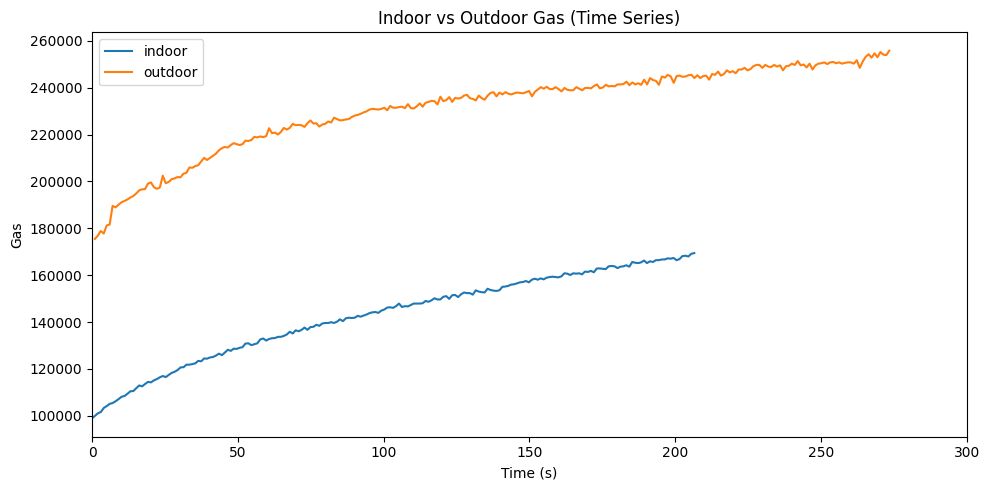

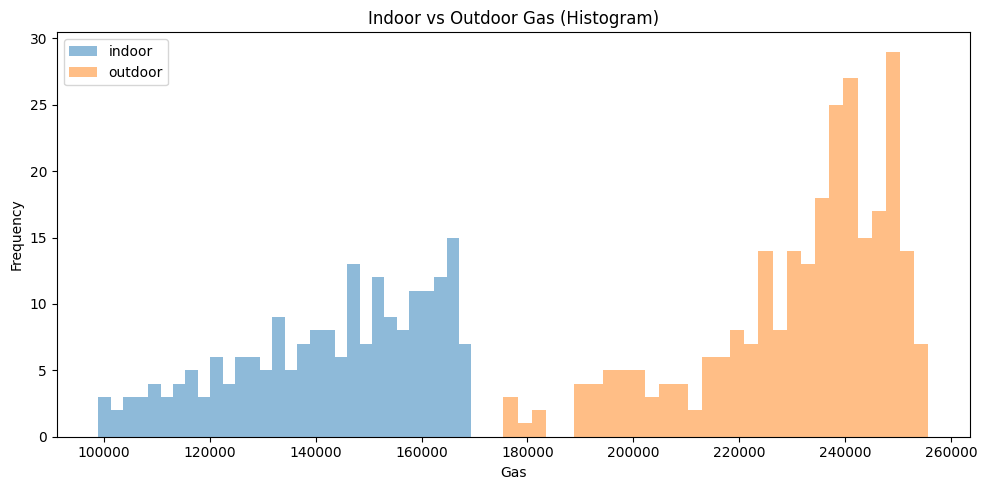


--- Gas ---
N indoor = 205, N outdoor = 270
Mean indoor  = 142669
Mean outdoor = 231403
Sigma (intrinsic) indoor  = 18512.3
Sigma (intrinsic) outdoor = 18019.8
Sigma_mean indoor  = 1292.95
Sigma_mean outdoor = 1096.65
|Δmean| = 88734.3
Combined sigma_mean (for Δ) = 1695.4
Separation (|Δmean| / σΔmean) = 52.3383 σ
Statistically different at > 3σ


In [8]:
# Gas
_ = plot_compare(indoor_fixed, outdoor_fixed, "Gas")

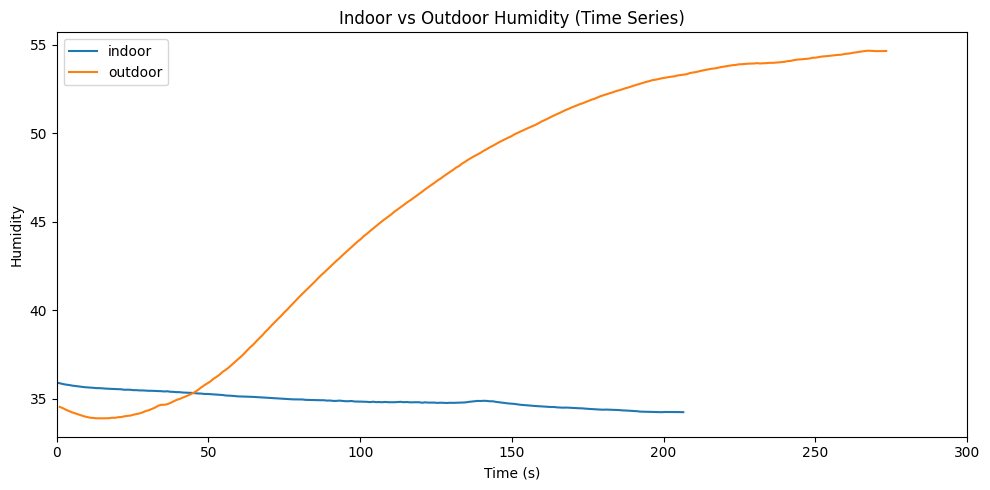

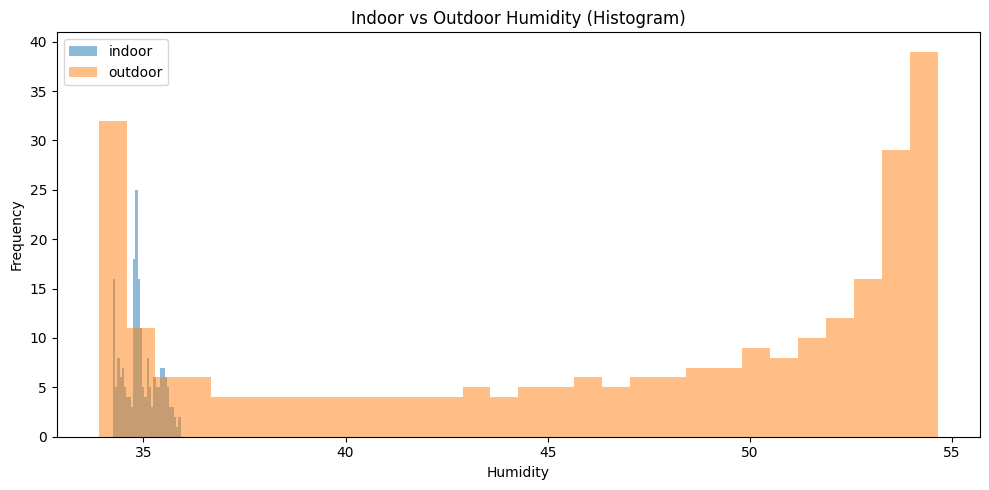


--- Humidity ---
N indoor = 205, N outdoor = 270
Mean indoor  = 34.9307
Mean outdoor = 46.2079
Sigma (intrinsic) indoor  = 0.422224
Sigma (intrinsic) outdoor = 7.51589
Sigma_mean indoor  = 0.0294894
Sigma_mean outdoor = 0.457402
|Δmean| = 11.2772
Combined sigma_mean (for Δ) = 0.458352
Separation (|Δmean| / σΔmean) = 24.6038 σ
Statistically different at > 3σ


In [9]:
# Humidity
_ = plot_compare(indoor_fixed, outdoor_fixed, "Humidity")

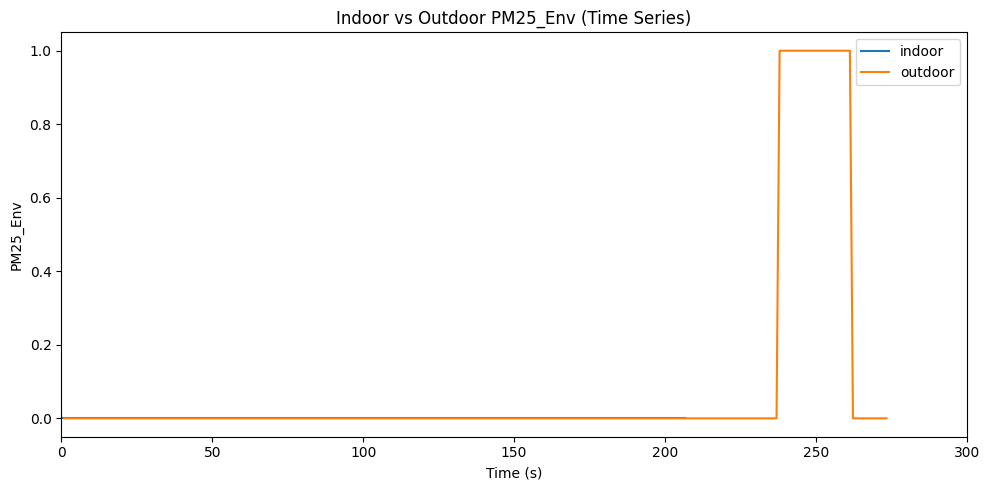

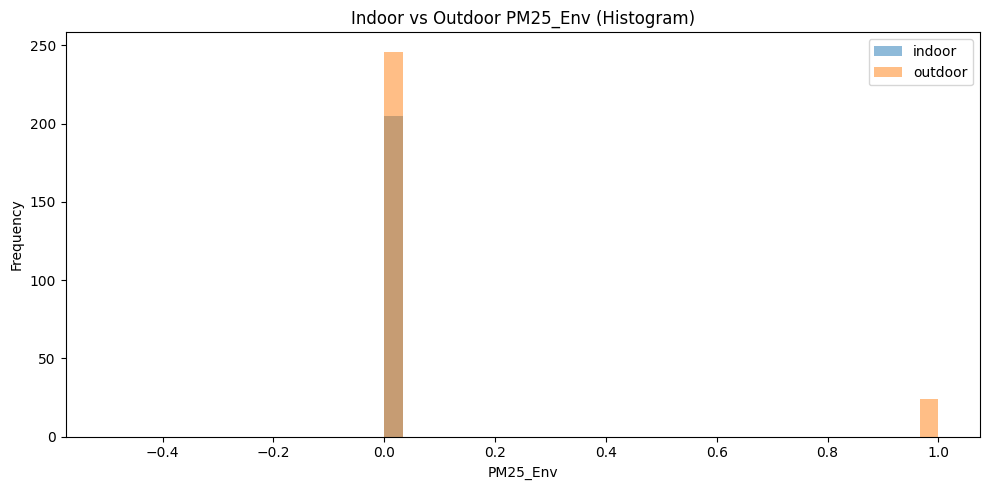


--- PM25_Env ---
N indoor = 205, N outdoor = 270
Mean indoor  = 0
Mean outdoor = 0.0888889
Sigma (intrinsic) indoor  = 0
Sigma (intrinsic) outdoor = 0.285112
Sigma_mean indoor  = 0
Sigma_mean outdoor = 0.0173514
|Δmean| = 0.0888889
Combined sigma_mean (for Δ) = 0.0173514
Separation (|Δmean| / σΔmean) = 5.12288 σ
Statistically different at > 3σ


In [10]:
# PM25_Env
_ = plot_compare(indoor_fixed, outdoor_fixed, "PM25_Env")

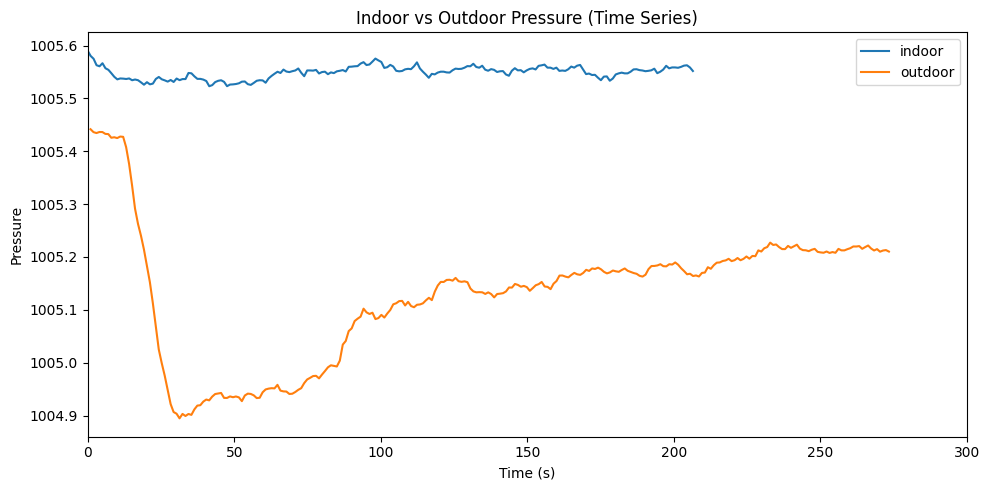

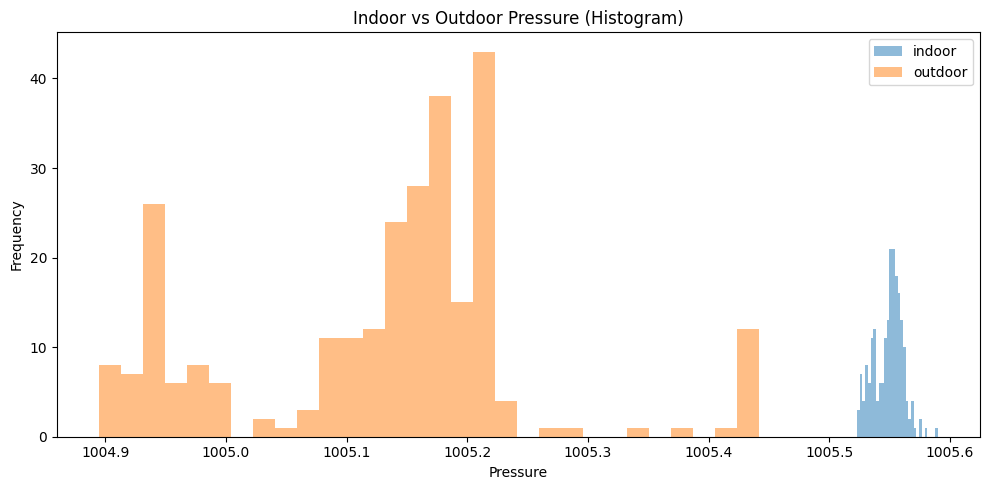


--- Pressure ---
N indoor = 205, N outdoor = 270
Mean indoor  = 1005.55
Mean outdoor = 1005.13
Sigma (intrinsic) indoor  = 0.01198
Sigma (intrinsic) outdoor = 0.122549
Sigma_mean indoor  = 0.000836721
Sigma_mean outdoor = 0.00745808
|Δmean| = 0.419131
Combined sigma_mean (for Δ) = 0.00750487
Separation (|Δmean| / σΔmean) = 55.8479 σ
Statistically different at > 3σ


In [11]:
# Pressure
_ = plot_compare(indoor_fixed, outdoor_fixed, "Pressure")

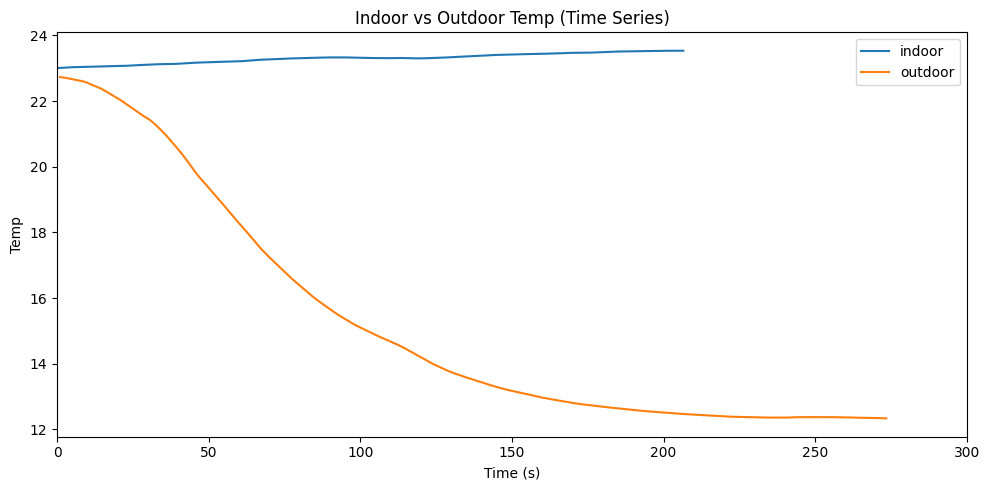

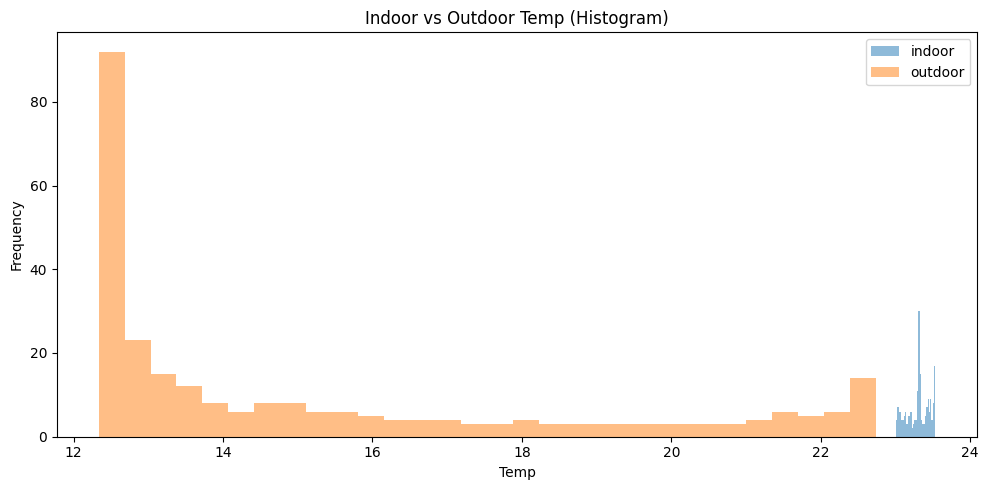


--- Temp ---
N indoor = 205, N outdoor = 270
Mean indoor  = 23.3049
Mean outdoor = 15.2517
Sigma (intrinsic) indoor  = 0.150796
Sigma (intrinsic) outdoor = 3.44587
Sigma_mean indoor  = 0.010532
Sigma_mean outdoor = 0.209709
|Δmean| = 8.05319
Combined sigma_mean (for Δ) = 0.209973
Separation (|Δmean| / σΔmean) = 38.3534 σ
Statistically different at > 3σ


In [12]:
# Temp
_ = plot_compare(indoor_fixed, outdoor_fixed, "Temp")

In [13]:
# Summary table (all variables)
all_results = []
for v in variables:
    s = stats_and_test(pd.to_numeric(indoor_fixed.get(v, pd.Series(dtype=float)), errors="coerce"),
                       pd.to_numeric(outdoor_fixed.get(v, pd.Series(dtype=float)), errors="coerce"))
    s["variable"] = v
    all_results.append(s)

summary = pd.DataFrame(all_results)[[
    "variable", "n_in", "n_out",
    "mean_in", "mean_out",
    "sigma_in", "sigma_out",
    "sigma_mean_in", "sigma_mean_out",
    "n_sigma", "different_3sigma"
]]
display(summary)

,variable,n_in,n_out,mean_in,mean_out,sigma_in,sigma_out,sigma_mean_in,sigma_mean_out,n_sigma,different_3sigma
0,Gas,205,270,142668.995122,231403.277778,18512.260029,18019.831045,1292.952325,1096.651994,52.338348,True
1,Humidity,205,270,34.930737,46.207930,0.422224,7.515888,0.029489,0.457402,24.603782,True
2,PM25_Env,205,270,0.000000,0.088889,0.000000,0.285112,0.000000,0.017351,5.122880,True
3,Pressure,205,270,1005.549078,1005.129947,0.011980,0.122549,0.000837,0.007458,55.847863,True
4,Temp,205,270,23.304924,15.251737,0.150796,3.445867,0.010532,0.209709,38.353419,True


### Analysis

Overall, the outdoor measurements tend to be much more distributed than the indoor data measurements despite the initial 30 second time mask on the outdoor data. Also, the indoor data tends to be much more Gaussian than the outdoor data due to this, so it is likely that more outdoor data needs to be collected for the central limit theorem to apply. The only exceptions to this are outdoor pressure and gas measurements, which appear to follow Gaussian statsistics somewhat more than other outdoor variables, and PM_25 air quality measurements which are non-Gaussian for both indoor and outdoor data, due to the very low count rate, which is always 0 or 1 per measurement. All measurements collected inside vs outside were found to be statistically different to greater than 99.7% confidence, that is the means of each measurement were separated by at least 3 indoor mean standard deviations. 